In [1]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Carga del dataset CICIDS2017 desde Kaggle

import kagglehub

# Descargar dataset desde Kaggle
path = kagglehub.dataset_download("dhoogla/cicids2017")

# Buscar todos los archivos Parquet dentro de la carpeta descargada
files = sorted(
    glob.glob(os.path.join(path, "**", "*.parquet"), recursive=True)
)

if not files:
    raise FileNotFoundError("No se encontraron archivos Parquet.")

# Cargar cada archivo y mostrar su nombre
df_list = []

for file in files:
    print(f"Cargando: {os.path.basename(file)}")
    df_list.append(pd.read_parquet(file))

# Unir todos los archivos en un único DataFrame y eliminar duplicados
df = pd.concat(df_list, ignore_index=True).drop_duplicates()

# resumen de los datos cargados
print(f"\nArchivos cargados: {len(files)}")
print(f"Registros finales: {len(df):,}")
print(f"Columnas: {df.shape[1]}")

Using Colab cache for faster access to the 'cicids2017' dataset.
Cargando: Benign-Monday-no-metadata.parquet
Cargando: Botnet-Friday-no-metadata.parquet
Cargando: Bruteforce-Tuesday-no-metadata.parquet
Cargando: DDoS-Friday-no-metadata.parquet
Cargando: DoS-Wednesday-no-metadata.parquet
Cargando: Infiltration-Thursday-no-metadata.parquet
Cargando: Portscan-Friday-no-metadata.parquet
Cargando: WebAttacks-Thursday-no-metadata.parquet

Archivos cargados: 8
Registros finales: 2,231,806
Columnas: 78


In [3]:
# SEPARAR FEATURES Y TARGET

X = df.drop(columns=['Label'])
y = df['Label']

print(f"Features: {X.shape[1]}")
print(f"Registros: {X.shape[0]:,}")

Features: 77
Registros: 2,231,806


In [4]:
# LIMPIEZA DE VALORES INVÁLIDOS

# Reemplazar infinitos por NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Eliminar filas con valores faltantes
valid_rows = X.notna().all(axis=1)

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print(f"Registros después de limpieza: {len(X):,}")

Registros después de limpieza: 2,231,806


In [5]:
# ELIMINAR FEATURES CONSTANTES

constant_cols = X.columns[X.nunique() <= 1]

X = X.drop(columns=constant_cols)

print(f"Features eliminadas: {len(constant_cols)}")
print(f"Features restantes: {X.shape[1]}")

Features eliminadas: 8
Features restantes: 69


In [6]:
# Comprobar features duplicadas

sample = X.sample(min(100000, len(X)), random_state=42)

duplicated_cols = sample.columns[sample.T.duplicated()].tolist()

print(f"Features duplicadas encontradas: {len(duplicated_cols)}")
print("Features duplicadas:")

for col in duplicated_cols:
    print(f"- {col}")

    # Eliminar features exactamente duplicadas

X = X.drop(columns=duplicated_cols, errors='ignore')

print(f"Features restantes: {X.shape[1]}")

Features duplicadas encontradas: 8
Features duplicadas:
- SYN Flag Count
- CWE Flag Count
- ECE Flag Count
- Avg Fwd Segment Size
- Avg Bwd Segment Size
- Subflow Fwd Packets
- Subflow Fwd Bytes
- Subflow Bwd Packets
Features restantes: 61


In [7]:
# ANÁLISIS DE CORRELACIÓN

# Calcular la correlación absoluta entre las features
corr = X.corr().abs()

# Seleccionar solamente la parte superior de la matriz
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

# Mostrar pares con correlación superior al 95%
high_corr = (
    upper.stack()
    .sort_values(ascending=False)
)

print("Pares con correlación > 0.95:")
display(high_corr[high_corr > 0.95].head(30))

Pares con correlación > 0.95:


Bwd Packets Length Total  Subflow Bwd Bytes           1.000000
Total Fwd Packets         Total Backward Packets      0.999070
Flow Duration             Fwd IAT Total               0.998492
Packet Length Mean        Avg Packet Size             0.998256
Flow IAT Max              Fwd IAT Max                 0.998016
Total Fwd Packets         Bwd Packets Length Total    0.996994
                          Subflow Bwd Bytes           0.996988
Total Backward Packets    Bwd Packets Length Total    0.994430
                          Subflow Bwd Bytes           0.994425
Idle Mean                 Idle Max                    0.990054
                          Idle Min                    0.989915
Flow IAT Max              Idle Max                    0.989302
Fwd IAT Max               Idle Max                    0.988422
Packet Length Max         Packet Length Std           0.983653
Bwd Packet Length Max     Bwd Packet Length Std       0.982205
Flow IAT Max              Idle Mean                   0.979496
Fwd IAT Max               Idle Mean                   0.977825
Fwd Packet Length Max     Fwd Packet Length Std       0.969201
Idle Max                  Idle Min                    0.960571
Flow Packets/s            Fwd Packets/s               0.960561
Bwd Packet Length Max     Bwd Packet Length Mean      0.956966
Flow IAT Max              Idle Min                    0.950397
dtype: float64

In [8]:
features_remove = [
    # Redundância praticamente total
    'Subflow Bwd Bytes',       # ≈ Bwd Packets Length Total
    'Subflow Fwd Bytes',       # ≈ Fwd Packets Length Total

    # Métrica muito próxima
    'Avg Packet Size',         # ≈ Packet Length Mean

    # Redundância temporal muito alta
    'Fwd IAT Max',

    # Redundância entre flags
    'ECE Flag Count',

    # Redundância entre métricas Idle
    'Idle Max',
    'Idle Min',
]

X = X.drop(columns=features_remove, errors='ignore')

print(f"Features restantes: {X.shape[1]}")

Features restantes: 56


In [9]:
# Clasificación binaria: Normal (0) vs Attack (1)

# Crear la variable objetivo binaria

# Benign = 0 → tráfico normal
# Cualquier otro tipo de tráfico = 1 → ataque

y = (df['Label'] != 'Benign').astype(int)

# Verificar la distribución
print("Distribución de clases:")
print(y.value_counts())

print("\nPorcentaje:")
print((y.value_counts(normalize=True) * 100).round(2))

Distribución de clases:
Label
0    1895314
1     336492
Name: count, dtype: int64

Porcentaje:
Label
0    84.92
1    15.08
Name: proportion, dtype: float64


In [10]:
# Mostrar ejemplos
print(
    pd.DataFrame({
        'Label_original': df['Label'],
        'Label_binaria': y
    }).drop_duplicates().sort_values('Label_binaria')
)

                     Label_original  Label_binaria
0                            Benign              0
481989                          Bot              1
645659                  FTP-Patator              1
780797                  SSH-Patator              1
1042827                        DDoS              1
1252064               DoS slowloris              1
1310269            DoS Slowhttptest              1
1315573                    DoS Hulk              1
1511532               DoS GoldenEye              1
1751625                  Heartbleed              1
1892435                Infiltration              1
2039911                    PortScan              1
2170216    Web Attack � Brute Force              1
2225587            Web Attack � XSS              1
2241767  Web Attack � Sql Injection              1


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:")
print(X_train.shape)

print("\nTest:")
print(X_test.shape)

Train:
(1785444, 56)

Test:
(446362, 56)


In [12]:
# StandardScaler

scaler = StandardScaler()

# Ajustar únicamente con Train
X_train_scaled = scaler.fit_transform(X_train)

# Aplicar la misma transformación a Test
X_test_scaled = scaler.transform(X_test)

print("StandardScaler aplicado correctamente.")

StandardScaler aplicado correctamente.


#Logistic Regression

In [13]:
# Logistic Regression - Normal vs Attack

from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

# Entrenar
model_lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = model_lr.predict(X_test_scaled)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [14]:
# Evaluación

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

print("===== Logistic Regression =====")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Normal', 'Attack'],
        zero_division=0
    )
)

===== Logistic Regression =====
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.97    379063
      Attack       0.74      0.97      0.84     67299

    accuracy                           0.94    446362
   macro avg       0.87      0.96      0.90    446362
weighted avg       0.96      0.94      0.95    446362



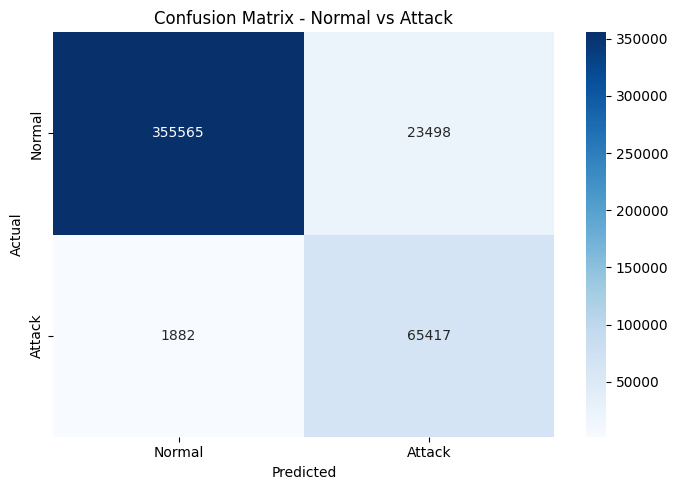

In [15]:
# Matriz de confusión

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Normal vs Attack")

plt.tight_layout()
plt.show()

#DNN

In [16]:
import keras
from keras import layers
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_dim = X_train_scaled.shape[1]
# Criar a rede neural
model_dnn = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
], name="dnn_classifier")

# Configurar treinamento
model_dnn.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model_dnn.summary()

Model: "dnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Entrenamiento

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    )
]

history = model_dnn.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=1024,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9784 - auc: 0.9923 - loss: 0.0640 - val_accuracy: 0.9870 - val_auc: 0.9971 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 2/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9871 - auc: 0.9970 - loss: 0.0368 - val_accuracy: 0.9882 - val_auc: 0.9983 - val_loss: 0.0300 - learning_rate: 0.0010
Epoch 3/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9882 - auc: 0.9977 - loss: 0.0321 - val_accuracy: 0.9885 - val_auc: 0.9985 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 4/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9887 - auc: 0.9980 - loss: 0.0301 - val_accuracy: 0.9895 - val_auc: 0.9989 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 5/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9890 - auc: 0.9982 - loss: 0.0285 - val_accuracy: 0.9904 - val_auc: 0.9990 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/20
1570/1570 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accura

In [18]:
# Probabilidade de ser Attack
y_prob_dnn = model_dnn.predict(X_test_scaled).ravel()

# Converter probabilidade em classe
y_pred_dnn = (y_prob_dnn >= 0.1).astype(int)

13949/13949 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step


In [19]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_dnn,
        target_names=['Normal', 'Attack']
    )
)


Classification Report:

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    379063
      Attack       0.94      0.99      0.96     67299

    accuracy                           0.99    446362
   macro avg       0.97      0.99      0.98    446362
weighted avg       0.99      0.99      0.99    446362



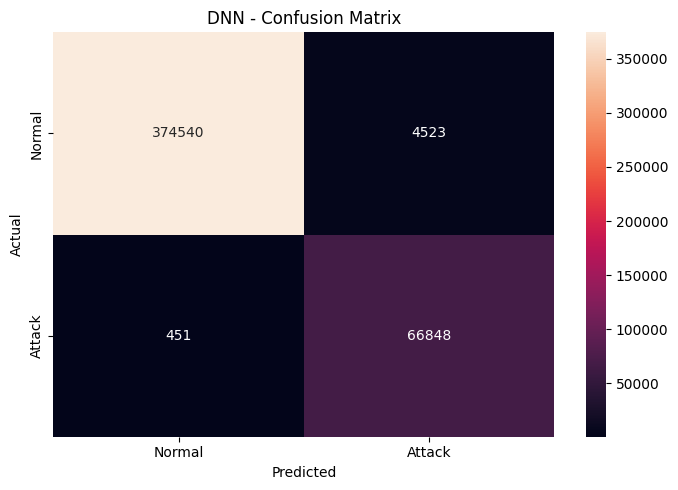

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_dnn)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DNN - Confusion Matrix')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob_dnn)
pr_auc = average_precision_score(y_test, y_prob_dnn)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9996
PR-AUC: 0.9981


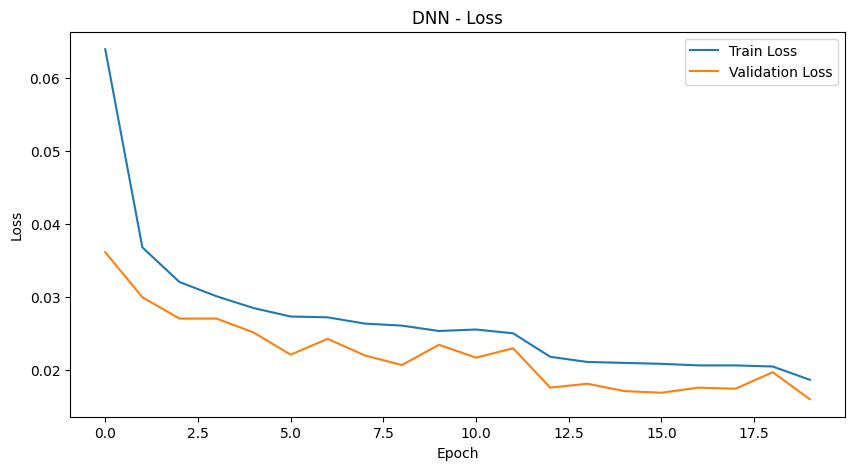

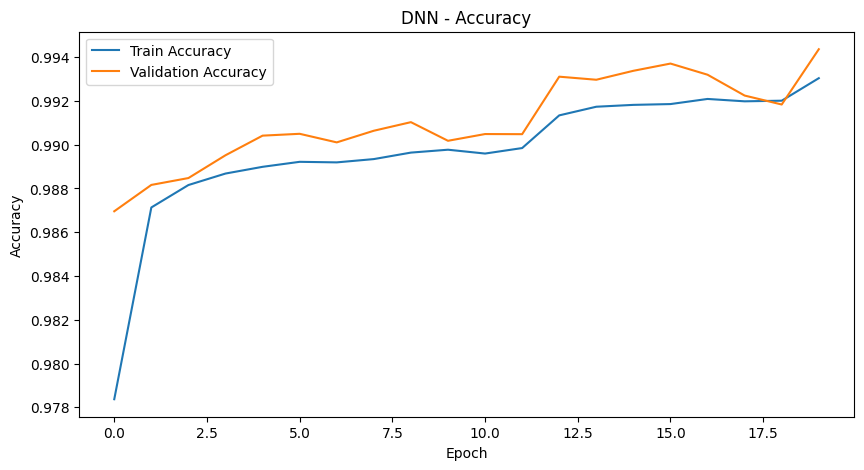

In [22]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Loss
plt.figure(figsize=(10, 5))

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DNN - Loss')
plt.legend()
plt.show()


# Accuracy
plt.figure(figsize=(10, 5))

plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DNN - Accuracy')
plt.legend()
plt.show()

#Comparar Logistic Regression × DNN

In [23]:
print("===== COMPARACIÓN =====")

print(f"Logistic Regression")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Macro : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, model_lr.predict_proba(X_test_scaled)[:, 1]):.4f}")

print("\nDNN")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dnn):.4f}")
print(f"F1 Macro : {f1_score(y_test, y_pred_dnn, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dnn):.4f}")

===== COMPARACIÓN =====
Logistic Regression
Accuracy : 0.9431
F1 Macro : 0.9015
ROC-AUC  : 0.9922

DNN
Accuracy : 0.9889
F1 Macro : 0.9788
ROC-AUC  : 0.9996


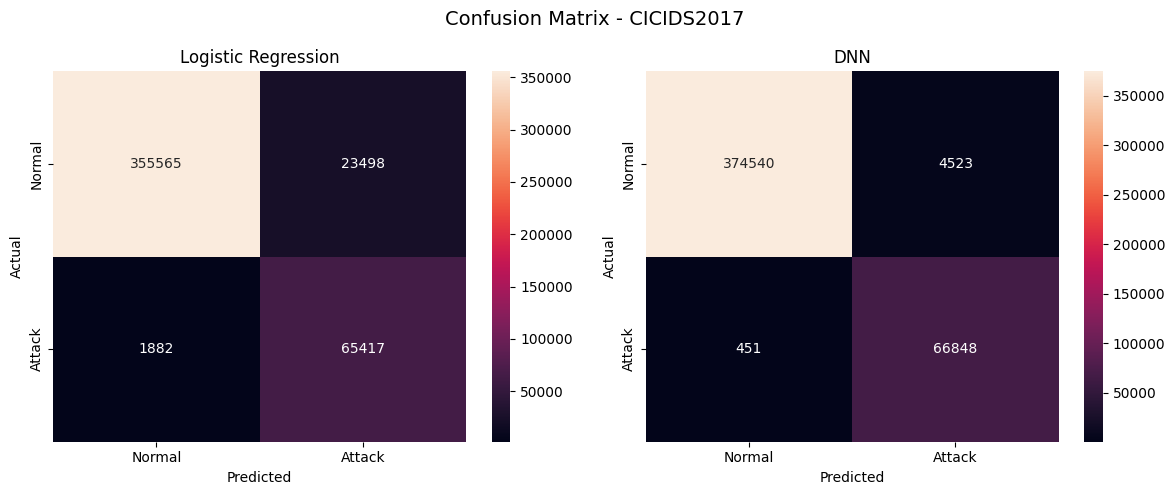

In [24]:
# MATRIZES DE CONFUSÃO

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    ax=axes[0],
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


# DNN
sns.heatmap(
    cm_dnn,
    annot=True,
    fmt='d',
    ax=axes[1],
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack']
)

axes[1].set_title('DNN')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle(
    'Confusion Matrix - CICIDS2017',
    fontsize=14
)

plt.tight_layout()
plt.show()

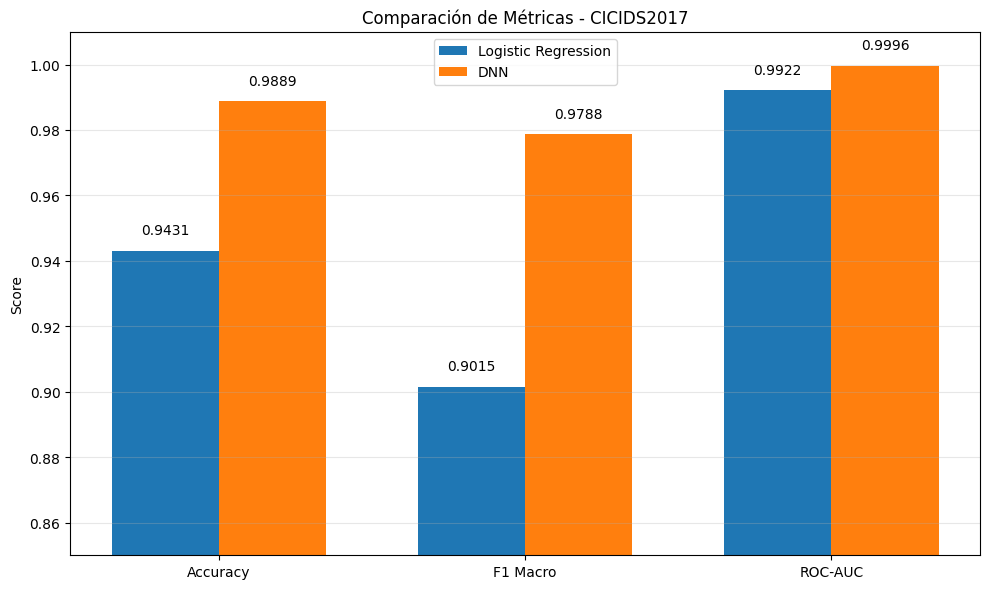

In [25]:
# 2. COMPARAÇÃO DAS MÉTRICAS

metrics_lr = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'F1 Macro': f1_score(y_test, y_pred_lr, average='macro'),
    'ROC-AUC': roc_auc_score(
        y_test,
        model_lr.predict_proba(X_test_scaled)[:, 1]
    )
}

metrics_dnn = {
    'Accuracy': accuracy_score(y_test, y_pred_dnn),
    'F1 Macro': f1_score(y_test, y_pred_dnn, average='macro'),
    'ROC-AUC': roc_auc_score(y_test, y_prob_dnn)
}

metrics = list(metrics_lr.keys())

lr_values = [metrics_lr[m] for m in metrics]
dnn_values = [metrics_dnn[m] for m in metrics]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width/2 for i in x],
    lr_values,
    width,
    label='Logistic Regression'
)

plt.bar(
    [i + width/2 for i in x],
    dnn_values,
    width,
    label='DNN'
)

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.ylim(0.85, 1.01)

plt.title('Comparación de Métricas - CICIDS2017')

plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar valores sobre las barras
for i, value in enumerate(lr_values):
    plt.text(
        i - width/2,
        value + 0.005,
        f'{value:.4f}',
        ha='center'
    )

for i, value in enumerate(dnn_values):
    plt.text(
        i + width/2,
        value + 0.005,
        f'{value:.4f}',
        ha='center'
    )

plt.tight_layout()
plt.show()
